In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from google.colab import drive

drive.mount('/content/drive')

import os

os.chdir("/content/drive/MyDrive/PCD_Tugas_1")
print(os.getcwd())
print(os.listdir())

Mounted at /content/drive
/content/drive/MyDrive/PCD_Tugas_1
['newyork.jpg', 'mugshot.jpg', 'lion.jpg', 'Untitled1.ipynb']


In [5]:
# Read image
img = cv2.imread("/content/drive/MyDrive/PCD_Tugas_1/lion.jpg")

# Convert BGR -> RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Original size:", img.shape)

Original size: (600, 587, 3)


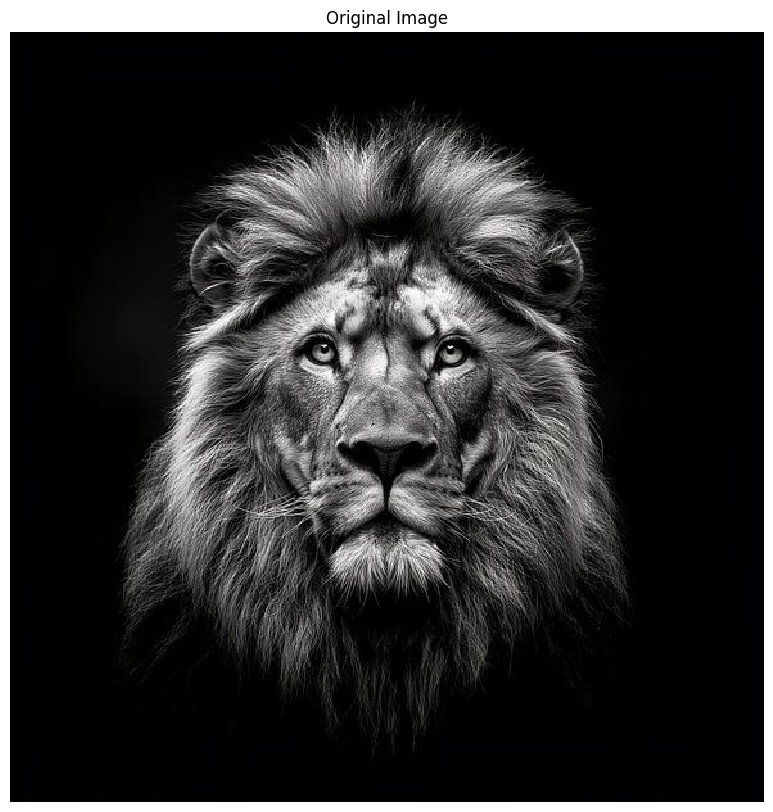

In [6]:
plt.figure(figsize=(14, 10))
plt.imshow(img, interpolation='none')
plt.title("Original Image")
plt.axis("off")
plt.show()

# Downsampling

## Max Downsampling


In [7]:
def max_downsampling(img, scale=0.5):
    h, w = img.shape[:2]
    new_h = int(h * scale)
    new_w = int(w * scale)

    block_h = h // new_h
    block_w = w // new_w

    # Crop so dimensions are divisible by block size
    cropped = img[:new_h * block_h, :new_w * block_w]

    # Reshape into blocks
    if len(img.shape) == 3:
        c = img.shape[2]
        reshaped = cropped.reshape(
            new_h, block_h,
            new_w, block_w,
            c
        )
        result = reshaped.max(axis=(1, 3))
    else:
        reshaped = cropped.reshape(
            new_h, block_h,
            new_w, block_w
        )
        result = reshaped.max(axis=(1, 3))

    return result.astype(np.uint8)

## Average Downsampling

In [8]:
def average_downsampling(img, scale=0.5):
    h, w = img.shape[:2]
    new_h = int(h * scale)
    new_w = int(w * scale)

    block_h = h // new_h
    block_w = w // new_w

    cropped = img[:new_h * block_h, :new_w * block_w]

    if len(img.shape) == 3:
        c = img.shape[2]
        reshaped = cropped.reshape(
            new_h, block_h,
            new_w, block_w,
            c
        )
        result = reshaped.mean(axis=(1, 3))
    else:
        reshaped = cropped.reshape(
            new_h, block_h,
            new_w, block_w
        )
        result = reshaped.mean(axis=(1, 3))

    return result.astype(np.uint8)

## Median Downsampling

In [9]:
def median_downsampling(img, scale=0.5):
    h, w = img.shape[:2]
    new_h = int(h * scale)
    new_w = int(w * scale)

    block_h = h // new_h
    block_w = w // new_w

    cropped = img[:new_h * block_h, :new_w * block_w]

    if len(img.shape) == 3:
        c = img.shape[2]
        reshaped = cropped.reshape(
            new_h, block_h,
            new_w, block_w,
            c
        )
        result = np.median(reshaped, axis=(1, 3))
    else:
        reshaped = cropped.reshape(
            new_h, block_h,
            new_w, block_w
        )
        result = np.median(reshaped, axis=(1, 3))

    return result.astype(np.uint8)

# Apply & Display

In [10]:
max_down = max_downsampling(img)
average_down = average_downsampling(img)
median_down = median_downsampling(img)

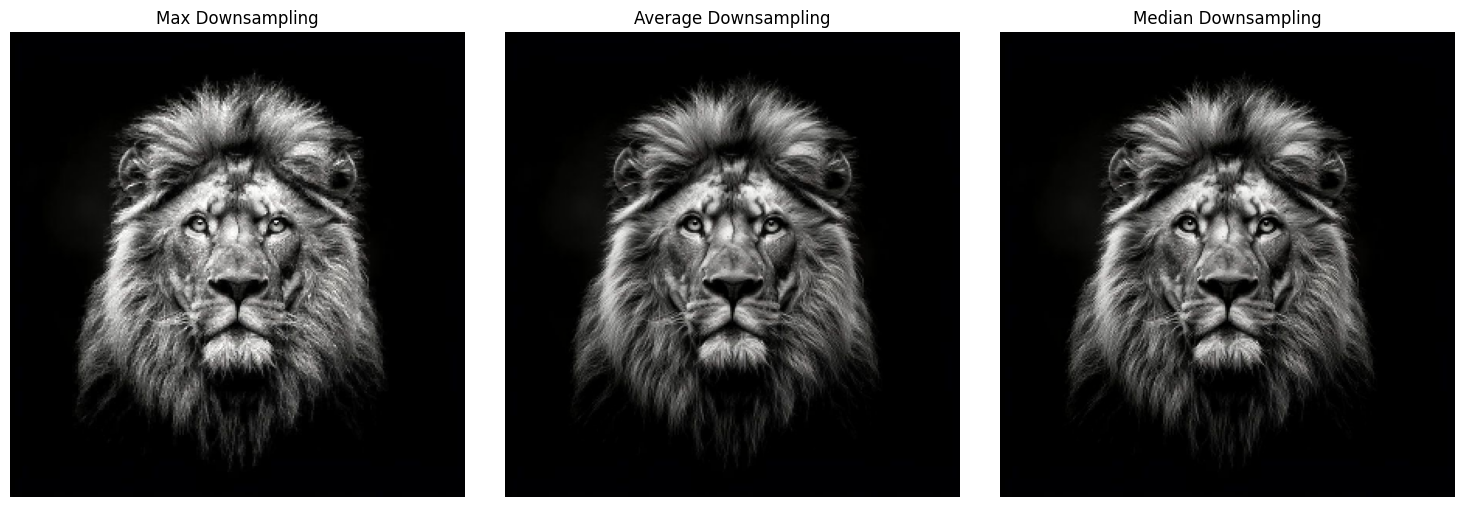

In [11]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(max_down)
plt.title("Max Downsampling")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(average_down)
plt.title("Average Downsampling")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(median_down)
plt.title("Median Downsampling")
plt.axis("off")

plt.tight_layout()

plt.show()

# Upsampling

## Nearest Neighbour

In [12]:
h, w = img.shape[:2]

nearest = cv2.resize(
    img,
    (w * 2, h * 2),
    interpolation=cv2.INTER_NEAREST
)

## Bilinear

In [13]:
bilinear = cv2.resize(
    img,
    (w * 2, h * 2),
    interpolation=cv2.INTER_LINEAR
)

## Bicubic

In [14]:
bicubic = cv2.resize(
    img,
    (w * 2, h * 2),
    interpolation=cv2.INTER_CUBIC
)

# Display

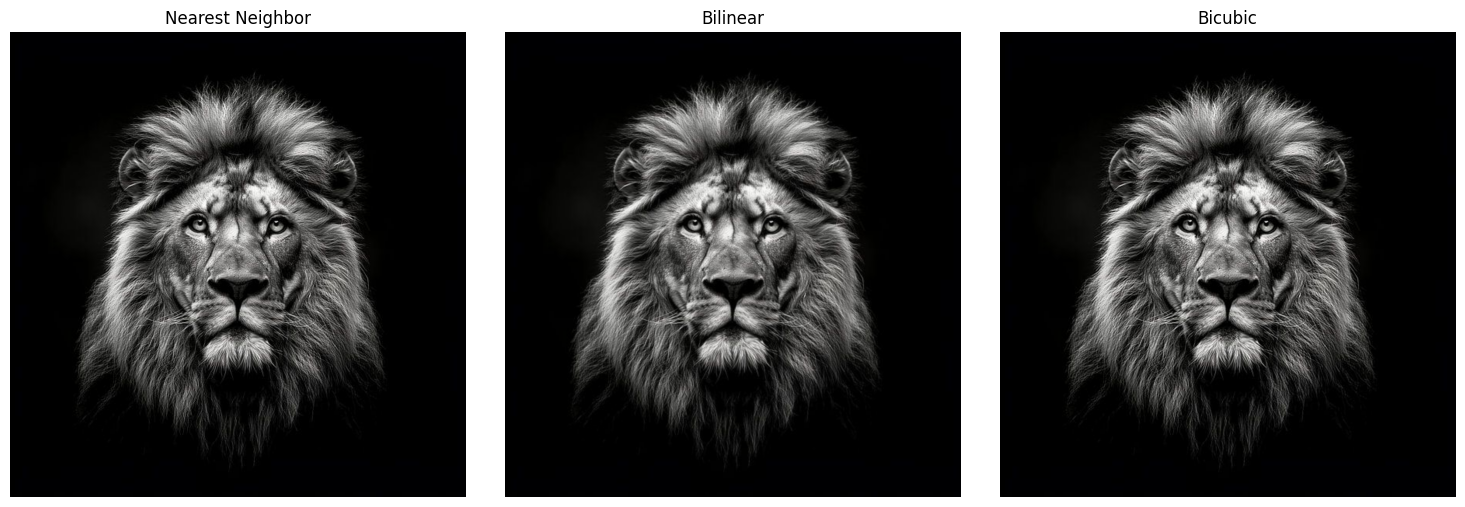

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(nearest)
plt.title("Nearest Neighbor")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bilinear)
plt.title("Bilinear")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bicubic)
plt.title("Bicubic")
plt.axis("off")

plt.tight_layout()

plt.show()

# Analysis

## Original vs Downsampled

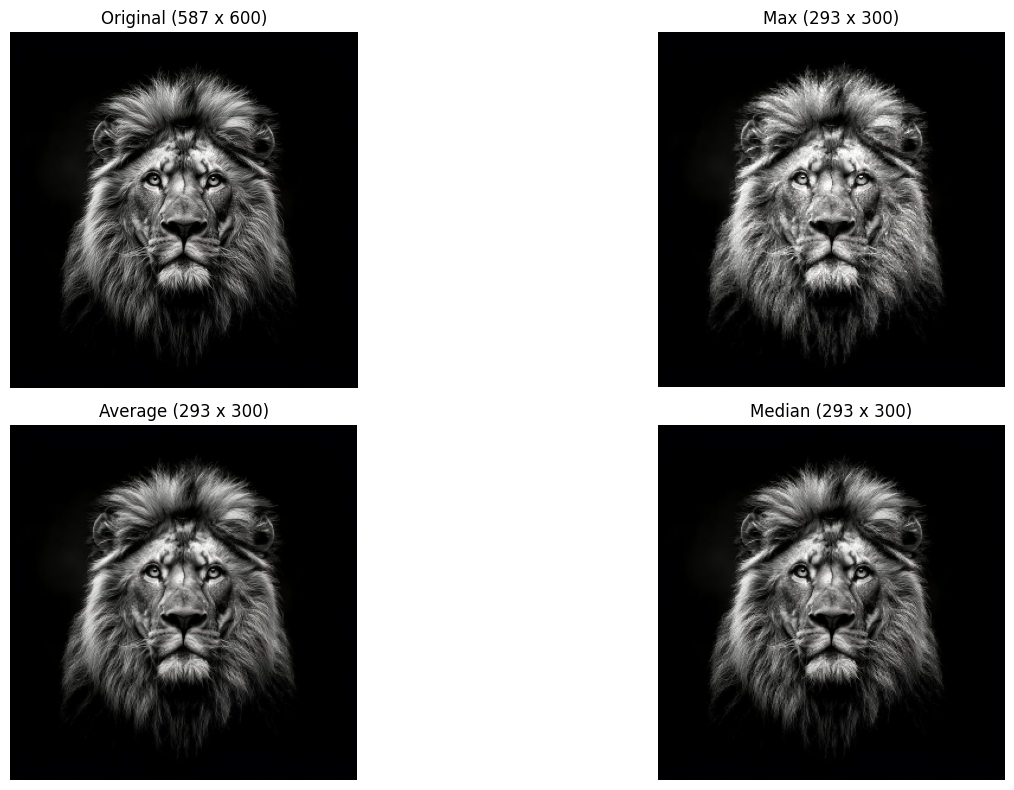

In [16]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title(f"Original ({img.shape[1]} x {img.shape[0]})")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(max_down)
plt.title(f"Max ({max_down.shape[1]} x {max_down.shape[0]})")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(average_down)
plt.title(f"Average ({average_down.shape[1]} x {average_down.shape[0]})")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(median_down)
plt.title(f"Median ({median_down.shape[1]} x {median_down.shape[0]})")
plt.axis("off")

plt.tight_layout()

plt.show()

## Original vs Upsampled

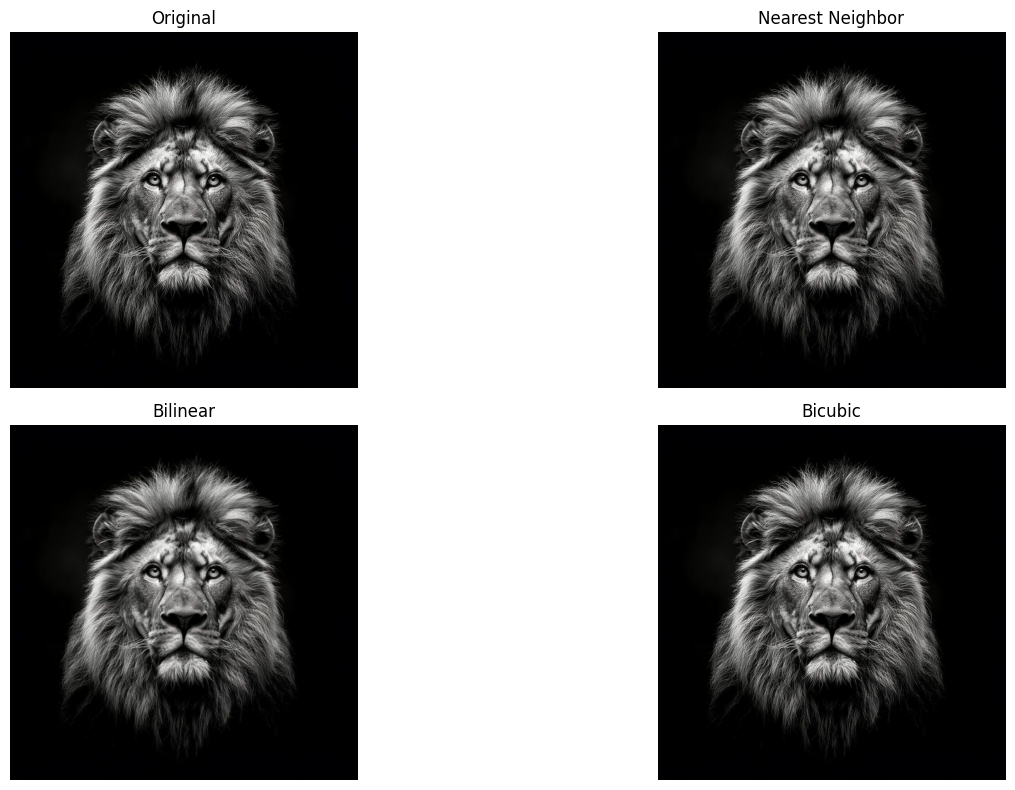

In [17]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(nearest)
plt.title("Nearest Neighbor")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(bilinear)
plt.title("Bilinear")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(bicubic)
plt.title("Bicubic")
plt.axis("off")

plt.tight_layout()

plt.show()